In [ ]:
# PROYECTO ANÁLISIS PREDICTIVO PARA UNA TIENDA MINORISTA: El proyecto busca pronosticar las ventas del año 2026 basándose en las ventas de años anteriores.

# Librerías y Módulos
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns
from sklearn.model_selection import train_test_split

# Importamos los modelos de regresión, ya que nuestra variable dependiente (Ventas) es numérica continua,
# no una categoría, por lo que necesitamos algoritmos de regresión y no de clasificación.
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

In [ ]:
# 1. Preparación de Datos
ruta = "C:/Users/noeli/Desktop/Big Data IA/ML/Aprendizaje Supervisado/Proyecto Análisis Predictivo Tienda Minorista/Ventas.csv"

df = pd.read_csv(ruta)
print(f"Primeros registros:\n{df.head()}\n")
print(f"Descripción:\n{df.describe()}\n")
print(f"Forma: {df.shape}\n")
print("Info:") 
df.info()  # No hay datos nulos. En Promociones y Festivo, el 0 indica "no" y el 1 "sí"
print(f"\nConteo duplicados: {df.duplicated().sum()}") # No hay ningún valor duplicado.

# El tipo de Fecha es object, por lo que conviene convertirlo a datetime.
df["Fecha"] = pd.to_datetime(df["Fecha"], format="%Y-%m-%d")

# 2. Elección de las variables independientes y de la variable dependiente
# Como variables independientes, tendremos a Mes, DíaDeLaSemana, Promociones y Festivo, y como variable dependiente a Ventas.
df["Mes"] = df["Fecha"].dt.month

X = df.drop(columns=["Ventas","Fecha"])
y = df["Ventas"]
# Creo Mes y elimino Fecha porque sklearn no puede trabajar con tipos datetime, necesita valores numéricos. Con "Mes" "DíaDeLaSemana", sklearn puede 
# entrenar igualmente, ya que capturan la información temporal relevante sin necesidad de la fecha completa (ya que, además, el año es el mismo para todos los registros)

# 3. Creación del conjunto de entrenamiento y del conjunto de prueba 
X_entrena, X_prueba, y_entrena, y_prueba = train_test_split(X, y, train_size=0.85, random_state=42)
# El grupo de entrenamiento contendrá el 85% de los datos y el de prueba el 15%, ya que considero que es la distribución más adecuada en base a la cantidad de datos existente.

# Con random_state garantizo la reproducibilidad de los resultados, ya que se fija la semilla del generador de números aleatorios que deciden que filas van a entrenamiento
# y cuales a prueba.

Primeros registros:
        Fecha  DíaDeLaSemana  Promociones  Festivo  Ventas
0  2022-01-01              6            0        0    4033
1  2022-01-02              7            0        1    4012
2  2022-01-03              1            0        0    1608
3  2022-01-04              2            1        0    2046
4  2022-01-05              3            0        0    2484

Descripción:
       DíaDeLaSemana  Promociones     Festivo       Ventas
count     365.000000   365.000000  365.000000   365.000000
mean        4.005479     0.200000    0.142466  2997.219178
std         2.002738     0.400549    0.350007   942.096284
min         1.000000     0.000000    0.000000  1305.000000
25%         2.000000     0.000000    0.000000  2195.000000
50%         4.000000     0.000000    0.000000  3074.000000
75%         6.000000     0.000000    0.000000  3979.000000
max         7.000000     1.000000    1.000000  4404.000000

Forma: (365, 5)

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 365 ent

Text(0.5, 0.98, 'Media de ventas de cada mes (promoción)')

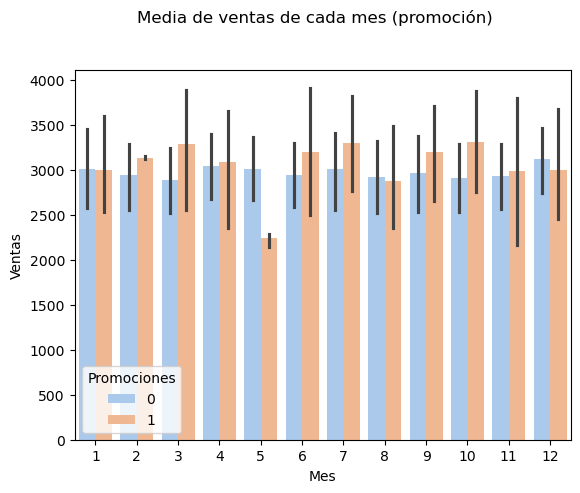

In [ ]:
# 4. Análisis Exploratorio de Datos
# 4.1 Media de las ventas de 2022 según el mes, diferenciadas según si se ha aplicado promoción o no.

g = sns.barplot(
    data=df,
    x="Mes",
    y="Ventas",
    hue="Promociones",
    palette="pastel"
)

g.figure.suptitle("Media de ventas de cada mes (promoción)", va="baseline", ha="center")

# No hay diferencias significativas a nivel de promoción dentro de cada mes, ya que si bien se observa que en la mayoría de meses las barras de promoción son algo superiores, 
# los intervalos de confianza de ambas barras se solapan. 
# La media de ventas entre los meses se mantiene bastante parecida (alrededor de 3000)

Text(0.5, 0.98, 'Media de ventas de cada mes (festivo)')

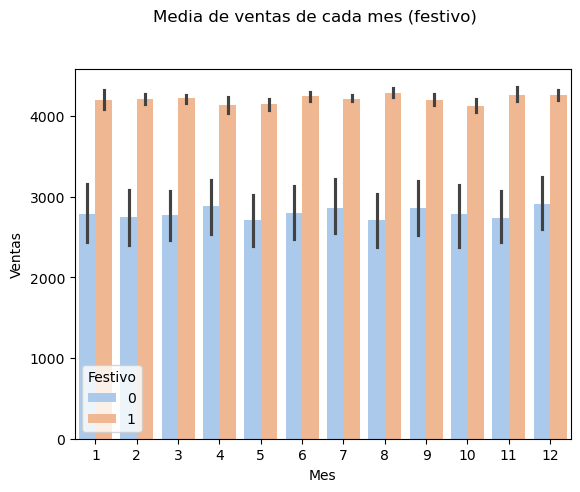

In [ ]:
# 4.2 Media de las ventas de 2022 según el mes, diferenciadas según si es festivo o no
g = sns.barplot(
    data=df,
    x="Mes",
    y="Ventas",
    hue="Festivo",
    palette="pastel"
)

g.figure.suptitle("Media de ventas de cada mes (festivo)", va="baseline", ha="center")

# En este caso si hay diferencias en las ventas según si es festivo o no: la media de ventas en festivo supera en 1000 a la media de ventas en días normales.
# Los intervalos de confianza no se solapan, por lo que esta diferencia es más fiable que la observada anteriormente con las promociones.

Text(0.5, 0.98, 'Media de ventas de cada día de la semana')

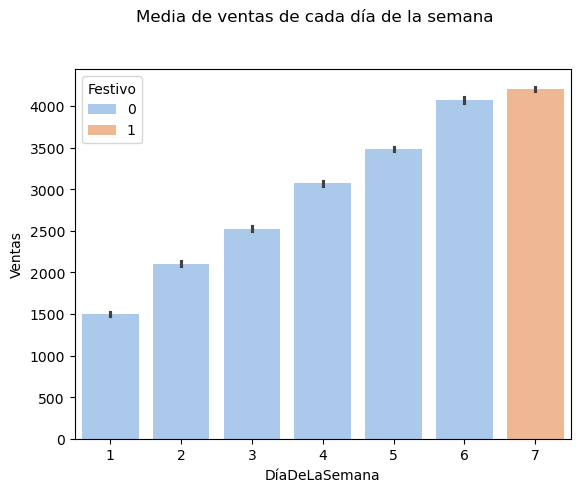

In [288]:
# 4.3 Día de la semana con más ventas
g = sns.barplot(
    data=df,
    x="DíaDeLaSemana",
    y="Ventas",
    hue="Festivo",
    palette="pastel"
)

g.figure.suptitle("Media de ventas de cada día de la semana", va="baseline", ha="center")

# El día de la semana con más ventas es el domingo, que a su vez es festivo y concuerda con lo visto en el anterior gráfico.

Text(0.5, 0.98, 'Relación del número de ventas a lo largo del tiempo')

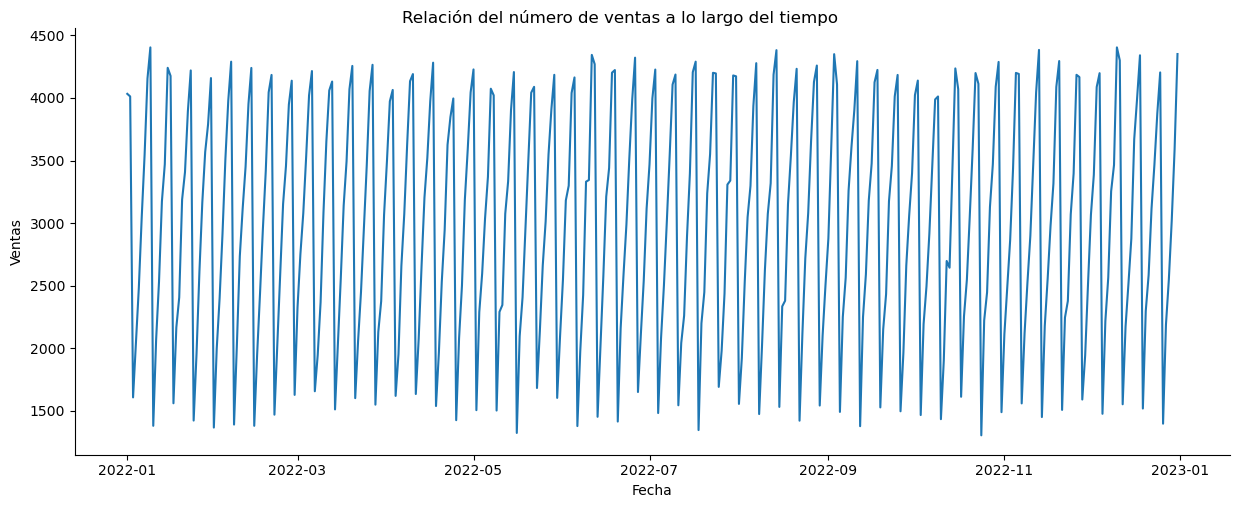

In [289]:
# 4.4 Ventas a lo largo del año 2022
g = sns.relplot(
    data=df,
    x="Fecha",
    y="Ventas",
    kind="line",
    height=5,
    aspect=2.5
) 
g.figure.suptitle("Relación del número de ventas a lo largo del tiempo", va="baseline", ha="center")

# Aquí vemos como se repite un mismo patrón de forma regular: cada diente es una semana, donde hay un pico (día de máximas ventas, domingo) y un valle 
# (día con menos ventas, lunes), manteniéndose constante de enero a diciembre. No hay tendencia de crecimiento ni caída a lo largo del año.

In [290]:
# 5. Selección del Modelo (¿Qué algoritmo es el más adecuado para entrenar a nuestro modelo?)

# Primero creamos la variable modelos, que contiene una lista de tuplas con cada modelo.
modelos = [("Regresión lineal", LinearRegression()), ("Árbol de Decisión", DecisionTreeRegressor()), ("Bosque Aleatorio", RandomForestRegressor())]

# Con un bucle for, iteramos y usamos todos los modelos.
for nombre, modelo in modelos:
    modelo.fit(X_entrena, y_entrena)
    puntaje = modelo.score(X_prueba, y_prueba)
    print(f"{nombre}: {puntaje:.4f}")

# El puntaje muestra que tanto árbol de decisión como Bosque Aleatorio tienen el mismo valor. En este caso, elegiré bosque aleatorio por ser un modelo
# más robusto y menos propenso al overfitting que un único Árbol de Decisión. Regresión Lineal también dio un resultado prácticamente igual, pero es preferible
# usar el Bosque Aleatorio ya que captura mejor las relaciones no lineales (el total de ventas no es la suma de cada variable por separado, sino que es el 
# resultado de la interacción de todas ellas)

Regresión lineal: 0.9921
Árbol de Decisión: 0.9881
Bosque Aleatorio: 0.9895


In [291]:
# 6. Entrenamiento y Evaluación del Modelo

# Llamamos al algoritmo de bosque aleatorio
forest = RandomForestRegressor()

# Entrenamos el modelo con el método FIT()
forest.fit(X_entrena, y_entrena)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [ ]:
# Evaluamos nuestro Modelo con SCORE() para ver el Coeficiente de Determinación ((R²))
forest.score(X_prueba, y_prueba) # El coeficiente de determinación es de 0.9894: el modelo explica el 98.9% de la variabilidad de las ventas.

0.9894204148263851

In [293]:
# 7. Ahora vamos a aplicar el Modelo Predictivo a un nuevo supuesto con el Método PREDICT()

dato_nuevo = pd.DataFrame({
    "DíaDeLaSemana": [7],
    "Promociones": [0],
    "Festivo": [1],
    "Mes": [7]
})

prediccion = forest.predict(dato_nuevo)
print(f"Ventas estimadas: {prediccion[0]:.0f}") # prediccion devuelve un array numpy, por lo que debemos poner el índice [0] para sacar el primer valor.

Ventas estimadas: 4211


In [ ]:
# 8. Comparación Ventas reales de 2022 vs Ventas predichas para 2026

# Para ello creo con Claude un csv llamado "ventas_2026_predecir", el cual tiene todas las columnas del csv original con nuevos datos, a excepción de Ventas, 
# que será una nueva columna con los valores que el modelo haya predecido.

ruta_2026 = "C:/Users/noeli/Desktop/Big Data IA/ML/Aprendizaje Supervisado/Proyecto Análisis Predictivo Tienda Minorista/ventas_2026_predecir.csv"

df_2026 = pd.read_csv(ruta_2026)

# Convierto el tipo de dato de Fecha a datetime, para posteriormente crear la columna "Mes" y hacer un drop de esta columna, puesto que a nivel de entrenamiento
# no estaba presente.

df_2026["Fecha"] = pd.to_datetime(df_2026["Fecha"], format="%Y-%m-%d")

df_2026["Mes"] = df_2026["Fecha"].dt.month

df_2026 = df_2026.drop(columns="Fecha")

# Con el método PREDICT() empleo el modelo para predecir las ventas de 2026 a lo largo del año.
predicciones = forest.predict(df_2026)

df_2026["Ventas"] = predicciones

In [ ]:
# 8.1 Gráfico comparativo entre las Ventas de 2022 y las Ventas de 2026

fig, axes = plt.subplots(ncols=2, figsize=(15,5))

ax1 = axes[0]
ax2 = axes[1]

# Usamos la función barplot (nivel axes), ya que ya tenemos creada una figura (relplot crea su propia figura desde 0, lineplot dibuja sobre ella)
sns.barplot(
    data=df,
    x="DíaDeLaSemana",
    y="Ventas",
    hue="Festivo",
    palette="bright",
    ax=axes[0]
)

sns.barplot(
    data=df_2026,
    x="DíaDeLaSemana",
    y="Ventas",
    hue="Festivo",
    palette="bright",
    ax=axes[1]
)

fig.suptitle("Comparación de ventas por día de la semana: real (2022) vs predicción (2026)", fontsize=14)

axes[0].grid(True)
axes[1].grid(True)
axes[0].set_xlabel("Día de la semana")
axes[1].set_xlabel("Día de la semana")
axes[0].set_title("Ventas 2022")
axes[1].set_title("Ventas 2026 (predicción)")

# Gráfico barplot que muestra la media de ventas según el día de la semana a lo largo del año, diferenciando si es festivo (Domingo) o no.
# Las ventas predichas para 2026 son casi idénticas que las de 2022, por lo que el modelo ha aprendido correctamente el patrón semanal 
# de ventas y el efecto de los festivos.

# No muestro el gráfico que diferencia según promoción ya que los datos de 2026 han sido generados de manera "aleatoria" en esa columna, ya que
# desconocemos la "lógica" que se ha seguido para establecer promociones en 2022.

        Variable  Importancia
0  DíaDeLaSemana     0.989555
3            Mes     0.005892
1    Promociones     0.003717
2        Festivo     0.000836


Text(0.5, 0.98, 'Importancia de cada variable según el Modelo')

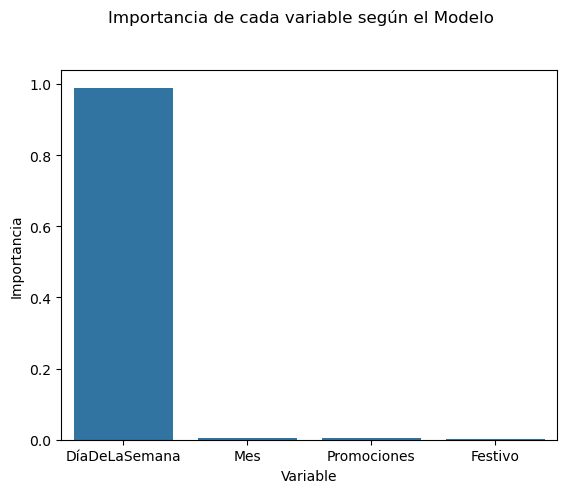

In [ ]:
# 9. Importancia de cada Variable en el Modelo con el Método feature_importances_

importancias = pd.DataFrame({
    "Variable": X_entrena.columns,
    "Importancia": forest.feature_importances_
    }).sort_values("Importancia", ascending=False)

print(importancias)

g = sns.barplot(
    data=importancias,
    x="Variable",
    y="Importancia"
)

g.figure.suptitle("Importancia de cada variable según el Modelo", va="baseline", ha="center")

# Por último, quiero reseñar la importancia de cada variable según el modelo, siendo la clara ganadora Día de la semana, ya que influye casi al 100% en las ventas.
# La variable Festivo realmente es redundante, puesto que el modelo ya sabe interpretar que el día 7 es el que tiene ventas más altas, sin necesidad de mirar 
# si es festivo (en el csv original, los únicos festivos son los domingos)

# Respecto a Promociones, aunque sí sigue un patrón en el dataset (solo aparece en martes y jueves), su importancia en el modelo es prácticamente nula, 
# ya que esos días no presentan diferencias claras en las ventas (ver gráfico 4.1)
# Lo mismo ocurre con la variable Mes, puesto que en ese mismo gráfico se observa que la media de ventas apenas varía según el mes.